
# Seminario de Estadística II - Tarea 2 Parte A

**Integrantes del equipo:**
* Azpeitia Medina Samuel
* Castro Pérez Juan Antonio
* Rodríguez Rodríguez Donovan Zuriel 

In [0]:
# Instalacion de la libreria para el Feature Store
%pip install databricks-feature-engineering

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Reiniciamos el proceso de Python para cargar la libreria
dbutils.library.restartPython()

### 1. Realice un análisis de la calidad de los datos de bronze a silver, elimine duplicados, conversión de tipos, missing vs ceros, lo que crea pertinente.

**Solución:**
Primero eliminamos registros duplicados para evitar que los resultados se distorsionen. Después, en las columnas de conteo y bytes, sustituimos los valores nulos por cero, ya que en este contexto un nulo normalmente significa ausencia de tráfico. Finalmente, convertimos esas variables a tipo long para trabajar de forma consistente en los cálculos posteriores.

In [0]:
import pyspark.sql.functions as F

# Cargamos la tabla silver
df_silver = spark.table("dev.ciencias_data.silver_sessions")

# Columnas numéricas que sí deben tener 0 en lugar de nulo
columnas_numericas = [
    "tot_packets",
    "src_packets",
    "dst_packets",
    "tot_bytes",
    "src_bytes",
    "dst_bytes",
    "tot_data_bytes"]

# Quitamos duplicados y rellenamos nulos con 0 en las columnas numéricas
df_limpio = df_silver.dropDuplicates().na.fill(0, subset=columnas_numericas)

# Convertimos esas columnas a enteros largos
for columna in columnas_numericas:
    df_limpio = df_limpio.withColumn(columna, F.col(columna).cast("long"))

# Sobrescribimos la tabla silver ya limpia
df_limpio.write.format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("dev.ciencias_data.silver_sessions")

df_limpio.limit(20).display()

timestamp,part_hour,src_ip,dst_ip,src_port,dst_port,src_mac,dst_mac,protocol,tot_packets,src_packets,dst_packets,tot_bytes,src_bytes,dst_bytes,tot_data_bytes,first_packet,last_packet,src_geo,dst_geo,http,packet_len_suma,packet_len_min,packet_len_max,packet_len_media
2020-03-23 18:24:18.003,2020-03-23-18,10.33.170.254,172.16.239.8,64015,8080,List(e8:1c:ba:f7:5f:72),List(e8:1c:ba:f0:32:5a),List(tcp),14,8,6,1252,480,772,0,2020-03-24T00:24:12.460Z,2020-03-24T00:24:12.486Z,null,null,null,1476,0,282,98.4
2020-03-23 23:07:08.009,2020-03-23-23,10.33.170.206,96.45.33.73,60058,8888,List(6c:0b:84:66:7c:e4),List(e8:1c:ba:f7:5f:72),List(udp),4,2,2,368,212,156,336,2020-03-24T05:06:37.784Z,2020-03-24T05:06:37.858Z,null,US,null,432,0,122,86.4
2020-03-23 18:24:20.002,2020-03-23-18,2620:0:cc6::169,2801:c4:15:200::ef,62651,53,List(2c:21:72:d0:78:f6),List(44:2b:03:53:d7:80),"List(udp, dns)",4,2,2,590,220,370,558,2020-03-24T00:23:49.079Z,2020-03-24T00:23:49.081Z,US,MX,null,654,0,201,130.8
2020-03-23 23:07:17.006,2020-03-23-23,10.10.8.22,10.20.1.250,0,0,List(00:08:e3:ff:fc:28),List(84:8a:8d:94:82:46),List(icmp),10,5,5,980,490,490,0,2020-03-24T05:07:02.368Z,2020-03-24T05:07:06.375Z,null,null,null,1140,0,114,103.63636363636364
2020-03-23 18:24:20.004,2020-03-23-18,10.10.16.197,10.33.255.108,50193,161,List(00:08:e3:ff:fc:28),List(00:23:eb:36:45:c1),"List(udp, snmp)",2,1,1,177,88,89,161,2020-03-24T00:23:49.161Z,2020-03-24T00:23:49.162Z,null,null,null,209,0,105,69.66666666666667
2020-03-23 23:07:19.003,2020-03-23-23,10.34.3.22,10.33.242.220,123,123,List(00:15:fa:c9:88:8d),List(40:ce:24:8a:ea:80),"List(udp, ntp)",2,2,0,180,180,0,164,2020-03-24T05:06:48.469Z,2020-03-24T05:06:48.469Z,null,null,null,212,0,106,70.66666666666667
2020-03-23 23:07:21.003,2020-03-23-23,200.78.173.253,187.189.183.202,47336,10010,List(4c:b1:6c:ed:1e:0d),List(94:10:3e:9c:86:bc),"List(http, tcp)",22,12,10,2892,1198,1694,786,2020-03-24T05:07:15.598Z,2020-03-24T05:07:15.790Z,MX,MX,List(List(187.189.183.202)),3244,0,617,141.04347826086956
2020-03-23 18:24:22.005,2020-03-23-18,10.33.224.203,52.185.211.133,63139,443,List(00:08:e3:ff:fc:28),List(00:09:0f:09:02:08),"List(tls, tcp)",44,22,22,13426,3996,9430,5447,2020-03-24T00:24:16.583Z,2020-03-24T00:24:16.739Z,null,US,List(List(settings-win.data.microsoft.com)),14130,0,1470,314.0
2020-03-23 23:07:28.007,2020-03-23-23,10.40.130.58,190.2.151.204,54226,80,"List(00:08:e3:ff:fc:28, 00:af:1f:60:9a:cd)","List(00:08:e3:ff:fc:28, 00:09:0f:09:02:08)","List(http, tcp)",27,15,12,3309,1674,1635,571,2020-03-24T05:07:21.776Z,2020-03-24T05:07:22.132Z,null,NL,List(List(b49.cleverjumper.com)),3741,0,379,133.60714285714286
2020-03-23 23:07:28.007,2020-03-23-23,2.5.5.2,10.128.0.1,26221,53,List(00:09:0f:09:00:09),List(00:09:0f:09:02:09),"List(udp, dns)",4,2,2,474,162,312,442,2020-03-24T05:06:57.342Z,2020-03-24T05:06:57.342Z,FR,null,null,538,0,172,107.6


### 2. Construya un FeatureStore para los datos de sesiones usando FeatureEngineeringClient() en databricks.

* **Construya las variables que crea pertinentes como duración de la sesión, bytes trasmitidos por unidad de tiempo, el tamaño promedio de los paquetes, ratio de bytes recibidos entre enviados etc.**

**Solución:**
Ahora vamos a generar las variables que nos servirán para el modelo. Calculamos la duración de la sesión, el ratio entre bytes recibidos y enviados, el tamaño promedio de los paquetes y los bytes por segundo. Al final generamos un identificador único para cada registro, que servirá como llave primaria.

In [0]:
import uuid
import pyspark.sql.functions as F
from pyspark.sql.types import StringType

# Cargamos la tabla silver ya limpia
df_entrenar = spark.table("dev.ciencias_data.silver_sessions")

# Duración de la sesión en segundos
df_entrenar = df_entrenar.withColumn(
    "duracion_seg",
    F.unix_timestamp(F.to_timestamp("last_packet")) - F.unix_timestamp(F.to_timestamp("first_packet")))

# Ratio de bytes recibidos entre enviados
df_entrenar = df_entrenar.withColumn(
    "ratio_recibido_enviado",
    F.when(F.col("src_bytes") > 0, F.col("dst_bytes") / F.col("src_bytes")).otherwise(0.0))

# Tamaño promedio de los paquetes
df_entrenar = df_entrenar.withColumn(
    "promedio_tamanio_paquete",
    F.when(F.col("tot_packets") > 0, F.col("tot_bytes") / F.col("tot_packets")).otherwise(0.0))

# Bytes por segundo
df_entrenar = df_entrenar.withColumn(
    "bytes_por_segundo",
    F.when(F.col("duracion_seg") > 0, F.col("tot_bytes") / F.col("duracion_seg")).otherwise(0.0))

# Función para generar un ID único
def get_uuid():
    return str(uuid.uuid4())

uuid_udf = F.udf(get_uuid, StringType())

# Agregamos la llave primaria
df_features = df_entrenar.withColumn("id", uuid_udf())

df_features.select(
    "id",
    "duracion_seg",
    "ratio_recibido_enviado",
    "promedio_tamanio_paquete",
    "bytes_por_segundo").limit(20).display()

id,duracion_seg,ratio_recibido_enviado,promedio_tamanio_paquete,bytes_por_segundo
b613d50e-54ed-4891-9e24-0226b3b9dbb0,0,1.6083333333333334,89.42857142857143,0.0
374e60ad-ec43-46ff-a537-2db974babfe1,0,0.7358490566037735,92.0,0.0
6569fd6d-ffcc-490c-a720-a4d85b36e783,0,1.6818181818181819,147.5,0.0
485b2fc9-7dd2-455b-ab7c-1b46c3265fc2,4,1.0,98.0,245.0
d5e264b8-398d-42dc-8e4e-1b7aba5b5867,0,1.0113636363636365,88.5,0.0
0b782edd-22e8-4258-8d13-00901d6639d8,0,0.0,90.0,0.0
e9f46f7d-f32e-431a-8d25-08cafd2a76f6,0,1.4140233722871451,131.45454545454547,0.0
b005e821-2a69-4a9f-bcd3-b33c90a19aa8,0,2.35985985985986,305.1363636363636,0.0
41df5342-5bd0-4428-b861-2ac98cb2613b,1,0.9767025089605734,122.55555555555556,3309.0
51a8542e-7286-45d1-8658-99222c01f393,0,1.9259259259259258,118.5,0.0


* **Registre el FeatureStore en Unity Catalog como se vio en clase.**

**Solución:**
Ahora vamos a dar de alta nuestras variables en el Feature Store. Primero creamos el esquema para que la tabla quede organizada en el catálogo y luego usamos el cliente de ingeniería de características para registrarla, indicando que la columna "id" es nuestra llave primaria.

In [0]:
from databricks.feature_engineering import FeatureEngineeringClient

# Creamos el esquema donde vivirá el Feature Store
spark.sql("CREATE SCHEMA IF NOT EXISTS dev.feature_store")

# Cliente de Feature Engineering
fe_client = FeatureEngineeringClient()

# Registro de la tabla de características
fe_client.create_table(
    name="dev.feature_store.sessions_arkime",
    primary_keys=["id"],
    df=df_features,
    schema=df_features.schema,
    description="Tabla con variables derivadas de sesiones de red para modelado")


<FeatureTable: name='dev.feature_store.sessions_arkime', table_id='992a8c8d-eadc-4bdd-8237-1b022f40e017', description='Tabla con las variables de duracion, ratios y promedios para el modelo de ML', primary_keys=['id'], partition_columns=[], features=['timestamp',
 'part_hour',
 'src_ip',
 'dst_ip',
 'src_port',
 'dst_port',
 'src_mac',
 'dst_mac',
 'protocol',
 'tot_packets',
 'src_packets',
 'dst_packets',
 'tot_bytes',
 'src_bytes',
 'dst_bytes',
 'tot_data_bytes',
 'first_packet',
 'last_packet',
 'src_geo',
 'dst_geo',
 'http',
 'packet_len_suma',
 'packet_len_min',
 'packet_len_max',
 'packet_len_media',
 'duracion_seg',
 'ratio_recibido_enviado',
 'promedio_tamanio_paquete',
 'id'], creation_timestamp=1774328941086, online_stores=[], notebook_producers=[], job_producers=[], table_data_sources=[], path_data_sources=[], custom_data_sources=[], timestamp_keys=[], tags={}>

### 3. Cree un Pipeline de datos donde implemente las diferentes técnicas de Feature Engineering vistos en la clase.
* **Construya el “set de entrenamiento” usando FeatureLookup y FeatureEngineeringClient.**

**Solución:**
En este paso construimos el conjunto de entrenamiento a partir de la tabla registrada en el Feature Store. Usamos FeatureLookup para recuperar las variables asociadas a cada id, y después cargamos el DataFrame final que se usará en el modelado.

In [0]:
from databricks.feature_engineering import FeatureLookup

# Tomamos solo las llaves primarias
df_base_ids = spark.table("dev.feature_store.sessions_arkime").select("id")

# Definimos la consulta de variables en el Feature Store
feature_lookups = [
    FeatureLookup(
        table_name="dev.feature_store.sessions_arkime",
        lookup_key="id")]

# Creamos el training set
set_entrenamiento = fe_client.create_training_set(
    df=df_base_ids,
    feature_lookups=feature_lookups,
    label=None,
    exclude_columns=["id"])

# Cargamos el dataframe final para modelado
df_entrenar = set_entrenamiento.load_df()

df_entrenar.limit(20).display()

timestamp,part_hour,src_ip,dst_ip,src_port,dst_port,src_mac,dst_mac,protocol,tot_packets,src_packets,dst_packets,tot_bytes,src_bytes,dst_bytes,tot_data_bytes,first_packet,last_packet,src_geo,dst_geo,http,packet_len_suma,packet_len_min,packet_len_max,packet_len_media,duracion_seg,ratio_recibido_enviado,promedio_tamanio_paquete
2020-03-23 18:24:38.003,2020-03-23-18,2620:0:cc6::167,2801:c4:15:200::e1,59323,53,List(2c:21:72:d0:78:f6),List(44:2b:03:53:d7:80),"List(udp, dns)",2,2,0,214,214,0,198,2020-03-24T00:24:07.663Z,2020-03-24T00:24:07.663Z,US,MX,null,246,0,123,82.0,0,0.0,107.0
2020-03-23 23:07:28.007,2020-03-23-23,10.40.130.58,190.2.151.204,54226,80,"List(00:08:e3:ff:fc:28, 00:af:1f:60:9a:cd)","List(00:08:e3:ff:fc:28, 00:09:0f:09:02:08)","List(http, tcp)",27,15,12,3309,1674,1635,571,2020-03-24T05:07:21.776Z,2020-03-24T05:07:22.132Z,null,NL,List(List(b49.cleverjumper.com)),3741,0,379,133.60714285714286,1,0.9767025089605734,122.55555555555556
2020-03-23 23:07:19.003,2020-03-23-23,10.34.3.22,10.33.242.220,123,123,List(00:15:fa:c9:88:8d),List(40:ce:24:8a:ea:80),"List(udp, ntp)",2,2,0,180,180,0,164,2020-03-24T05:06:48.469Z,2020-03-24T05:06:48.469Z,null,null,null,212,0,106,70.66666666666667,0,0.0,90.0
2020-03-23 22:10:59.008,2020-03-23-22,10.33.225.70,172.217.9.3,61147,443,List(00:08:e3:ff:fc:28),List(00:09:0f:09:02:08),List(tcp),10,6,4,612,360,252,0,2020-03-24T04:10:24.596Z,2020-03-24T04:10:53.147Z,null,US,null,772,0,82,70.18181818181819,29,0.7,61.2
2020-03-23 22:11:02.002,2020-03-23-22,10.33.120.175,168.61.144.182,49518,443,"List(00:08:e3:ff:fc:28, 00:09:0f:09:02:12)","List(00:08:e3:ff:fc:28, 00:09:0f:09:02:08)","List(tls, tcp)",66,27,39,17106,3444,13662,4436,2020-03-24T04:10:56.154Z,2020-03-24T04:10:56.426Z,null,US,List(List(j5yrru.manage.trendmicro.com)),18162,0,1464,271.07462686567163,0,3.966898954703833,259.1818181818182
2020-03-23 23:07:21.003,2020-03-23-23,200.78.173.253,187.189.183.202,47336,10010,List(4c:b1:6c:ed:1e:0d),List(94:10:3e:9c:86:bc),"List(http, tcp)",22,12,10,2892,1198,1694,786,2020-03-24T05:07:15.598Z,2020-03-24T05:07:15.790Z,MX,MX,List(List(187.189.183.202)),3244,0,617,141.04347826086956,0,1.4140233722871451,131.45454545454547
2020-03-23 23:07:35.006,2020-03-23-23,192.151.112.162,187.188.92.141,55179,10009,List(00:08:e3:ff:fc:28),List(00:09:0f:09:02:08),"List(http, tcp)",22,10,12,2764,930,1834,726,2020-03-24T05:07:29.618Z,2020-03-24T05:07:29.736Z,US,MX,List(List(187.188.92.141)),3116,0,631,135.47826086956522,0,1.972043010752688,125.63636363636364
2020-03-23 18:24:45.006,2020-03-23-18,10.33.170.222,172.16.239.8,49585,8080,"List(6c:0b:84:66:7e:94, e8:1c:ba:f7:5f:72)","List(e8:1c:ba:f0:32:5a, e8:1c:ba:f7:5f:72)","List(http, tcp)",32,22,10,3738,1940,1798,759,2020-03-24T00:24:39.404Z,2020-03-24T00:24:39.412Z,null,null,"List(List(172.16.239.8:8080, 172.16.239.8))",4250,0,669,128.78787878787878,0,0.9268041237113402,116.8125
2020-03-23 23:07:08.009,2020-03-23-23,10.33.170.206,96.45.33.73,60058,8888,List(6c:0b:84:66:7c:e4),List(e8:1c:ba:f7:5f:72),List(udp),4,2,2,368,212,156,336,2020-03-24T05:06:37.784Z,2020-03-24T05:06:37.858Z,null,US,null,432,0,122,86.4,0,0.7358490566037735,92.0
2020-03-23 23:07:28.007,2020-03-23-23,2.5.5.2,10.128.0.1,26221,53,List(00:09:0f:09:00:09),List(00:09:0f:09:02:09),"List(udp, dns)",4,2,2,474,162,312,442,2020-03-24T05:06:57.342Z,2020-03-24T05:06:57.342Z,FR,null,null,538,0,172,107.6,0,1.9259259259259258,118.5


* **Realize un análisis de conglomerados, usando las diferentes técnicas como K-Means y DBSCAN.**

**Solución:**
Primero escalamos las variables numéricas y calculamos la inercia para varios valores de k. Con eso graficamos el método del codo y elegimos el número de grupos más razonable para K-Means.

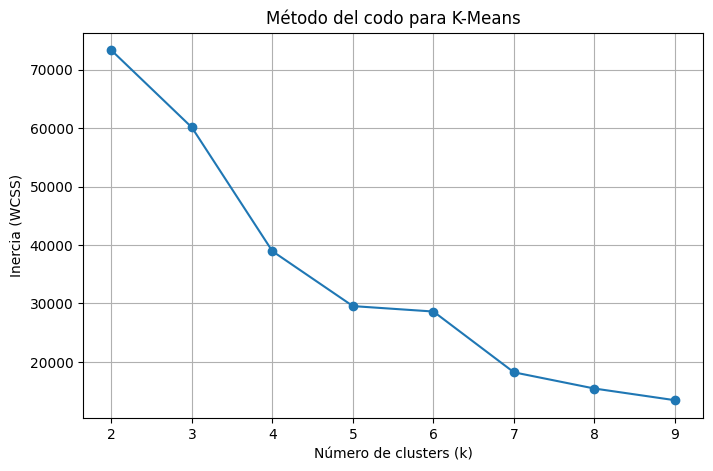

In [0]:
import matplotlib.pyplot as plt
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml import Pipeline

num_cols = [
    "duracion_seg",
    "promedio_tamanio_paquete",
    "tot_packets",
    "tot_bytes",
    "tot_data_bytes"]

df_base = df_entrenar.select(*num_cols).na.drop()

assembler = VectorAssembler(
    inputCols=num_cols,
    outputCol="features_unscaled",
    handleInvalid="skip")

scaler = StandardScaler(
    inputCol="features_unscaled",
    outputCol="features",
    withStd=True,
    withMean=True)

prep_model = Pipeline(stages=[assembler, scaler]).fit(df_base)
df_scaled = prep_model.transform(df_base).select("features")

inertias = []
k_range = range(2, 10)

for k in k_range:
    model = KMeans(
        k=k,
        seed=42,
        featuresCol="features",
        maxIter=10
    ).fit(df_scaled)
    inertias.append(model.summary.trainingCost)
    del model

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo para K-Means")
plt.grid(True)
plt.show()

Se entrena K-Means usando el valor de k=5 obtenido con el método del codo. Primero se construye el vector de características y se escalan las variables. Después se ajusta el modelo y se obtienen los clusters para cada sesión.

In [0]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import ClusteringEvaluator

# Variables del modelo
columnas_modelo = [
    "duracion_seg",
    "promedio_tamanio_paquete",
    "tot_packets",
    "tot_bytes",
    "tot_data_bytes"]

# Ensamblador
assembler = VectorAssembler(
    inputCols=columnas_modelo,
    outputCol="features_unscaled",
    handleInvalid="skip")

# Escalado
scaler = StandardScaler(
    inputCol="features_unscaled",
    outputCol="features",
    withStd=True,
    withMean=True)

# Modelo K-Means
kmeans = KMeans(
    k=5,
    seed=42,
    featuresCol="features",
    predictionCol="cluster")

# Pipeline completo
pipeline = Pipeline(stages=[assembler, scaler, kmeans])

# Entrenamiento
modelo = pipeline.fit(df_entrenar)

# Predicciones
df_clusters = modelo.transform(df_entrenar)

# Resultados
df_clusters.select("cluster", *columnas_modelo).limit(10).display()

cluster,duracion_seg,promedio_tamanio_paquete,tot_packets,tot_bytes,tot_data_bytes
0,0,89.42857142857143,14,1252,0
0,0,92.0,4,368,336
0,0,147.5,4,590,558
0,4,98.0,10,980,0
0,0,88.5,2,177,161
0,0,90.0,2,180,164
0,0,131.45454545454547,22,2892,786
0,0,305.1363636363636,44,13426,5447
0,1,122.55555555555556,27,3309,571
0,0,118.5,4,474,442


Se aplica DBSCAN para identificar agrupaciones por densidad y detectar posibles anomalías (ruido). Primero se estandarizan las variables y luego se reduce la dimensión con PCA a dos componentes para poder visualizar los resultados.

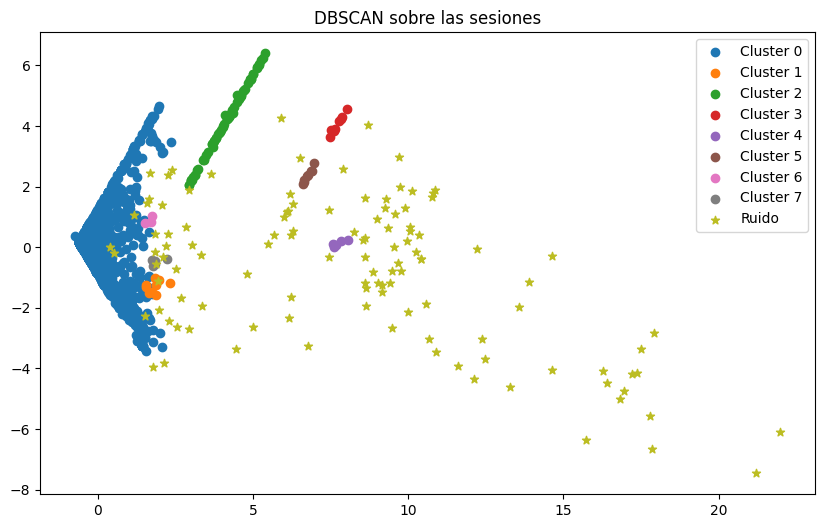

In [0]:
from sklearn.preprocessing import StandardScaler as SKScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Tomamos una muestra para evitar problemas de memoria
pdf = df_entrenar.select(
    "duracion_seg",
    "promedio_tamanio_paquete",
    "tot_packets",
    "tot_bytes",
    "tot_data_bytes").sample(fraction=0.2, seed=42).toPandas()

# Escalado
scaler = SKScaler()
X_scaled = scaler.fit_transform(pdf)

# PCA a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# DBSCAN
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5,
    metric="euclidean")

labels = dbscan.fit_predict(X_scaled)

# Gráfica
plt.figure(figsize=(10, 6))

for etiqueta in set(labels):
    mascara = labels == etiqueta
    if etiqueta == -1:
        plt.scatter(X_pca[mascara, 0], X_pca[mascara, 1], marker="*", label="Ruido")
    else:
        plt.scatter(X_pca[mascara, 0], X_pca[mascara, 1], label=f"Cluster {etiqueta}")

plt.title("DBSCAN sobre las sesiones")
plt.legend()
plt.show()

* **Implemente un modelo de detección de anomalías usando Isolation Forest.**

**Solución:** Se aplica Isolation Forest para detectar sesiones anómalas. Primero se escalan las variables, luego se entrena el modelo y se identifican las observaciones que se consideran fuera de lo normal.

In [0]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Variables del modelo
columnas_modelo = [
    "duracion_seg",
    "ratio_recibido_enviado",
    "promedio_tamanio_paquete",
    "tot_packets",
    "tot_bytes",
    "src_bytes",
    "dst_bytes"]

# Convertimos a pandas (con muestra para evitar problemas de memoria)
df_pandas = df_entrenar.select(columnas_modelo).sample(fraction=0.2, seed=42).toPandas()

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pandas)

# Modelo Isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42)

# Predicciones
df_pandas["anomalia"] = iso_forest.fit_predict(X_scaled)
df_pandas["score"] = iso_forest.score_samples(X_scaled)

# Etiquetas
df_pandas["anomalia"] = df_pandas["anomalia"].map({1: "Normal", -1: "Anómalo"})

# Resumen
total = len(df_pandas)
anomalias = (df_pandas["anomalia"] == "Anómalo").sum()

print(f"Total: {total}")
print(f"Anómalos: {anomalias} ({anomalias/total*100:.2f}%)")
print(f"Normales: {total - anomalias} ({(total-anomalias)/total*100:.2f}%)")

df_pandas.head()

Total: 5129
Anómalos: 257 (5.01%)
Normales: 4872 (94.99%)


,duracion_seg,ratio_recibido_enviado,promedio_tamanio_paquete,tot_packets,tot_bytes,src_bytes,dst_bytes,anomalia,score
0,0,1.608333,89.428571,14,1252,480,772,Normal,-0.329322
1,0,1.681818,147.500000,4,590,220,370,Normal,-0.322245
2,0,1.011364,88.500000,2,177,88,89,Normal,-0.316838
3,0,1.414023,131.454545,22,2892,1198,1694,Normal,-0.327987
4,3,1.000000,106.000000,8,848,424,424,Normal,-0.322775


Para visualizar los resultados del modelo, proyectamos los datos a dos dimensiones usando PCA y marcamos las observaciones detectadas como anomalías.

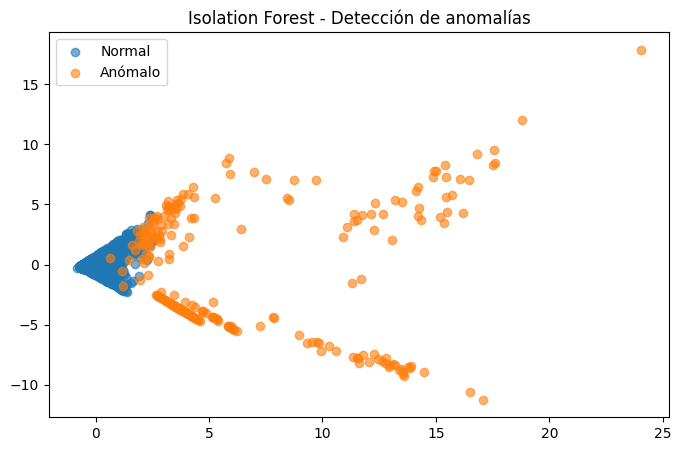

In [0]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reducimos a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Graficamos
plt.figure(figsize=(8,5))

for etiqueta in df_pandas["anomalia"].unique():
    mask = df_pandas["anomalia"] == etiqueta
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=etiqueta,
        alpha=0.6)

plt.title("Isolation Forest - Detección de anomalías")
plt.legend()
plt.show()

* **Comparta sus conclusiones de manera detallada, incluyendo como determino los perfiles de comportamiento y grupos.**

**Solución:**

A partir del análisis realizado, se identificaron patrones de comportamiento en las sesiones de red utilizando técnicas de clustering y detección de anomalías.

Primero, mediante el método del codo se determinó un valor adecuado de k, lo que permitió aplicar K-Means para segmentar las sesiones en distintos grupos. Cada cluster representa un perfil de comportamiento con características similares en términos de duración, volumen de datos y número de paquetes.

En general, se observaron tres tipos de comportamiento:
- Sesiones cortas con bajo volumen de datos, asociadas a tráfico ligero o consultas simples.
- Sesiones más largas con mayor número de paquetes y bytes, correspondientes a transferencias de información.
- Sesiones con comportamiento más irregular, donde destacan relaciones atípicas entre bytes enviados y recibidos.

Posteriormente, se aplicó DBSCAN, lo que permitió identificar grupos basados en densidad y, especialmente, detectar puntos aislados que no pertenecen a ningún cluster, interpretados como posibles valores atípicos.

Finalmente, con Isolation Forest se detectaron anomalías de forma más explícita. Estas sesiones anómalas presentan características que se alejan del comportamiento general, como duraciones extremas, volúmenes de datos inusuales o proporciones atípicas entre envío y recepción.

En conjunto, el uso de estas técnicas permitió no solo agrupar las sesiones según su comportamiento, sino también identificar observaciones que podrían representar actividad inusual o potencialmente sospechosa dentro de la red.

* **Valide la calidad de su clusterización, ¿Qué observa?**

**Solución:** Para validar la calidad de la clusterización se utilizó el coeficiente de Silhouette, el cual mide qué tan bien separados están los grupos y qué tan compactos son internamente. Este valor toma valores entre -1 y 1, donde valores cercanos a 1 indican una buena separación entre clusters.

In [0]:
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(
    predictionCol="cluster",
    featuresCol="features",
    metricName="silhouette"
)

silhouette = evaluator.evaluate(df_clusters)
print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.7625


El Silhouette Score obtenido es de **0.7625**, lo cual indica una clusterización de buena calidad.

Este valor cercano a 1 sugiere que los grupos están bien definidos, con alta cohesión interna y buena separación entre clusters.

Esto confirma que las variables utilizadas capturan adecuadamente los distintos patrones de comportamiento en el tráfico de red, y que la elección de k es consistente con la estructura de los datos.

### 4. Para el ejemplo visto en clase sobre clustering jerárquico, realice el mismo ejemplo utilizando el enlace completo.

**Solución:**

Para el método de enlace completo, la distancia entre dos clústeres se toma como la distancia máxima entre cualquier par de elementos de ambos grupos:

d(A,B) = max { d(xi, xj) } para xi en A, xj en B.

Empezamos con la matriz de distancias original, donde cada delegación es un clúster individual:

| | Milpa Alta | Tláhuac | Iztapalapa | Tlalpan | Xochimilco | Coyoacán |
|:---|:---:|:---:|:---:|:---:|:---:|:---:|
| Milpa Alta | 0 | 33.2 | 31.3 | 25.7 | 11.4 | 39.6 |
| Tláhuac | 33.2 | 0 | 8.6 | 18.5 | 15.8 | 15.4 |
| Iztapalapa | 31.3 | 8.6 | 0 | 18.7 | 16.0 | 15.3 |
| Tlalpan | 25.7 | 18.5 | 18.7 | 0 | 9.3 | 11.1 |
| Xochimilco | 11.4 | 15.8 | 16.0 | 9.3 | 0 | 15.3 |
| Coyoacán | 39.6 | 15.4 | 15.3 | 11.1 | 15.3 | 0 |

La distancia mínima en la matriz es 8.6, que corresponde a Tláhuac e Iztapalapa. Los agrupamos formando el clúster {Tláhuac, Iztapalapa}.

Recalculamos las distancias de este nuevo clúster hacia los demás usando siempre el valor máximo:
* d({Tláhuac, Iztap.}, MA) = max(33.2, 31.3) = 33.2
* d({Tláhuac, Iztap.}, Tlalpan) = max(18.5, 18.7) = 18.7
* d({Tláhuac, Iztap.}, Xochimilco) = max(15.8, 16.0) = 16.0
* d({Tláhuac, Iztap.}, Coyoacán) = max(15.4, 15.3) = 15.4

Matriz actualizada:

| | {Tláhuac, Iztap.} | Milpa Alta | Tlalpan | Xochimilco | Coyoacán |
|:---|:---:|:---:|:---:|:---:|:---:|
| {Tláhuac, Iztap.}| 0 | 33.2 | 18.7 | 16.0 | 15.4 |
| Milpa Alta | 33.2 | 0 | 25.7 | 11.4 | 39.6 |
| Tlalpan | 18.7 | 25.7 | 0 | 9.3 | 11.1 |
| Xochimilco | 16.0 | 11.4 | 9.3 | 0 | 15.3 |
| Coyoacán | 15.4 | 39.6 | 11.1 | 15.3 | 0 |

Ahora la nueva distancia mínima en la matriz es 9.3, entre Tlalpan y Xochimilco. Los agrupamos en el clúster {Tlalpan, Xochimilco}.

Recalculamos las distancias:
* d({Tlalpan, Xoch.}, {Tláhuac, Iztap.}) = max(18.7, 16.0) = 18.7
* d({Tlalpan, Xoch.}, MA) = max(25.7, 11.4) = 25.7
* d({Tlalpan, Xoch.}, Coyoacán) = max(11.1, 15.3) = 15.3

Matriz actualizada:

| | {Tláhuac, Iztap.} | {Tlalpan, Xoch.} | Milpa Alta | Coyoacán |
|:---|:---:|:---:|:---:|:---:|
| {Tláhuac, Iztap.}| 0 | 18.7 | 33.2 | 15.4 |
| {Tlalpan, Xoch.} | 18.7 | 0 | 25.7 | 15.3 |
| Milpa Alta | 33.2 | 25.7 | 0 | 39.6 |
| Coyoacán | 15.4 | 15.3 | 39.6 | 0 |

Buscamos de nuevo y la distancia mínima es 15.3, entre el clúster {Tlalpan, Xochimilco} y Coyoacán. Los unimos en {Tlalpan, Xochimilco, Coyoacán}.

Recalculamos las distancias:
* d({Tlalpan, Xoch., Coy.}, {Tláhuac, Iztap.}) = max(18.7, 15.4) = 18.7
* d({Tlalpan, Xoch., Coy.}, MA) = max(25.7, 39.6) = 39.6

Matriz actualizada:

| | {Tláhuac, Iztap.} | {Tlalpan, Xoch., Coy.} | Milpa Alta |
|:---|:---:|:---:|:---:|
| {Tláhuac, Iztap.}| 0 | 18.7 | 33.2 |
| {Tlalpan, Xoch., Coy.} | 18.7 | 0 | 39.6 |
| Milpa Alta | 33.2 | 39.6 | 0 |

En este punto la distancia mínima es 18.7, que corresponde a los clústeres {Tláhuac, Iztapalapa} y {Tlalpan, Xochimilco, Coyoacán}. Los juntamos en un solo grupo.

Calculamos la distancia restante con Milpa Alta:
* d({Tláhuac, Iztap., Tlalpan, Xoch., Coy.}, MA) = max(33.2, 39.6) = 39.6

Matriz actualizada:

| | {Tláhuac, Iztap., Tlalpan, Xoch., Coy.} | Milpa Alta |
|:---|:---:|:---:|
| {Tláhuac, Iztap., Tlalpan, Xoch., Coy.}| 0 | 39.6 |
| Milpa Alta | 39.6 | 0 |

Conclusión:

Si el gobierno de la CDMX requiere poner exactamente dos oficinas administrativas, nos detenemos antes de la última agrupación, lo que nos deja con los siguientes dos grupos:

Oficina 1: Tláhuac, Iztapalapa, Tlalpan, Xochimilco y Coyoacán.

Oficina 2: Milpa Alta.
